# Task 2 — EDA (Ethiopia)

This notebook performs a clean, reproducible EDA workflow for **Ethiopia** using the raw file:

- `data/ethiopia.csv`

It produces a cleaned dataset saved locally (and ignored by Git):

- `data/ethiopia_clean.csv`

The workflow follows the Week 0 requirements:

- Add `Country`
- Convert `YEAR` + `DOY` → `DATE` via `pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")`
- Extract `Month`
- Replace sentinel `-999` with `NaN`
- Remove duplicate rows
- Missingness report (counts/percentages; flag >5%)
- Z-score outlier flagging for core weather variables; decide an outlier strategy and justify
- Handle remaining missingness (drop rows >30% missing; forward-fill weather variables)
- Save cleaned output and generate required charts with interpretations


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cleaning import (
    clean_country_dataframe,
    missingness_report,
    numeric_describe,
    compute_zscores,
)
from src.io import load_raw_country_csv, save_cleaned_country_csv

sns.set_theme(style="whitegrid")

COUNTRY = "ethiopia"


## Load data

In [2]:
df_raw = load_raw_country_csv(COUNTRY)
df_raw.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## Clean + feature engineering

In [4]:
# We choose outlier_strategy="cap" to avoid removing real extreme-weather days.
# Capping reduces undue leverage on correlations/summary stats while preserving
# seasonality and rare-event frequency (important for climate risk narratives).

df, info = clean_country_dataframe(df_raw, COUNTRY, outlier_strategy="cap")
info


{'duplicates_removed': 0,
 'outlier_flagged_rows': 132,
 'outlier_flagged_by_col': {'PRECTOTCORR': 95,
  'T2M_MIN': 18,
  'RH2M': 13,
  'WS2M_MAX': 5,
  'T2M': 3,
  'WS2M': 3,
  'T2M_MAX': 0},
 'outlier_rows_dropped': 0,
 'rows_dropped_over_30pct_missing': 0}

## Summary statistics

In [5]:
desc = numeric_describe(df)
desc


,count,mean,std,min,25%,50%,75%,max
YEAR,4108.0,2020.131451,3.248907,2015.00000,2017.0000,2020.00,2023.0000,2026.00000
DOY,4108.0,180.121227,106.294767,1.00000,86.0000,179.00,272.0000,366.00000
T2M,4108.0,16.070465,1.891031,11.01000,14.8200,16.04,17.3600,21.17000
T2M_MAX,4108.0,23.199175,2.751471,15.65000,21.1100,22.74,25.1700,30.93000
T2M_MIN,4108.0,10.231836,2.593991,2.71375,8.4175,10.99,12.2200,15.68000
T2M_RANGE,4108.0,12.971631,3.821239,3.56000,9.8300,13.03,16.0200,23.24000
PRECTOTCORR,4108.0,2.877663,3.851544,0.00000,0.0200,0.82,4.5800,11.42000
RH2M,4108.0,68.423936,14.689191,26.37125,59.0300,71.12,80.8025,91.93000
WS2M,4108.0,1.979988,0.689062,0.46000,1.4075,1.97,2.4800,4.08875
WS2M_MAX,4108.0,3.574720,1.122084,0.79000,2.7200,3.53,4.3700,6.84500


## Missing values

In [6]:
miss = missingness_report(df)
pd.DataFrame({"missing_count": miss.counts, "missing_pct": miss.percentages}).head(20)


,missing_count,missing_pct
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Missingness interpretation

The table above lists missing counts and percentages by column (top 20). Columns with **> 5%** missing are flagged for attention.

In climate time series, small gaps are common (sensor/collection issues). We handle remaining gaps by:

- **Dropping** rows with more than **30%** missing values (likely low-quality days)
- **Forward-filling** core weather variables (reasonable for short gaps in daily data)


## Outliers

In [7]:
out = compute_zscores(df)
out.flagged_counts.head(10)


WS2M           3
T2M_MAX        0
T2M            0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M_MAX       0
dtype: int64

## Outliers decision

We flagged outliers using **z-scores** on core variables (abs(z) > 3). Instead of dropping these rows, we **cap** weather-variable outliers using an IQR-based clip.

**Why cap?**

- Climate extremes are often *real* and policy-relevant (heat waves, heavy rainfall).
- Dropping them can bias extreme-day counts and understate vulnerability.
- Capping prevents a small number of values from dominating correlations and summary statistics.


## Save cleaned output

In [8]:
out_path = save_cleaned_country_csv(df, COUNTRY)
out_path


WindowsPath('C:/Users/USER/Documents/Projects/10 academy/climate-challenge-week0/data/ethiopia_clean.csv')

## Visualizations

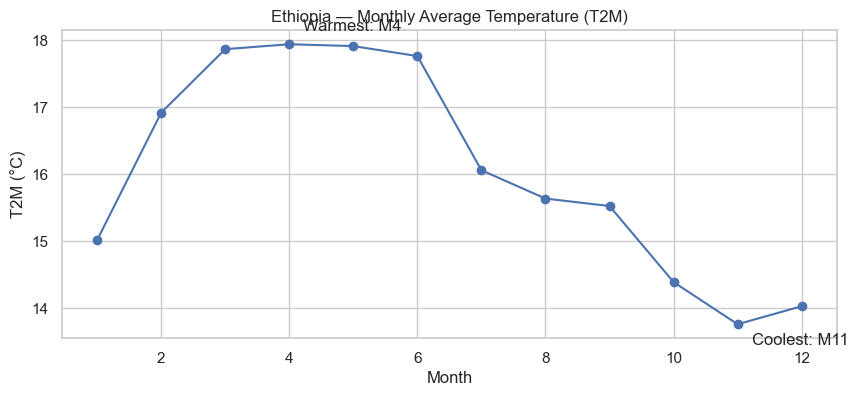

In [9]:
monthly = (
    df.groupby("Month", as_index=False)
    .agg(T2M_mean=("T2M", "mean"), PRECTOTCORR_sum=("PRECTOTCORR", "sum"))
    .sort_values("Month")
)

# 1) Monthly average T2M line chart + warmest/coolest annotation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["Month"], monthly["T2M_mean"], marker="o")
ax.set_title(f"{COUNTRY.title()} — Monthly Average Temperature (T2M)")
ax.set_xlabel("Month")
ax.set_ylabel("T2M (°C)")

warm = monthly.loc[monthly["T2M_mean"].idxmax()]
cool = monthly.loc[monthly["T2M_mean"].idxmin()]
ax.annotate(f"Warmest: M{int(warm['Month'])}", (warm["Month"], warm["T2M_mean"]),
            textcoords="offset points", xytext=(10, 10))
ax.annotate(f"Coolest: M{int(cool['Month'])}", (cool["Month"], cool["T2M_mean"]),
            textcoords="offset points", xytext=(10, -15))
plt.show()


## Interpretation (Monthly temperature)

The line chart shows the seasonal temperature cycle. The annotated warmest/coolest months highlight the strongest seasonal contrast, useful for discussing exposure to heat stress and the timing of hottest periods.


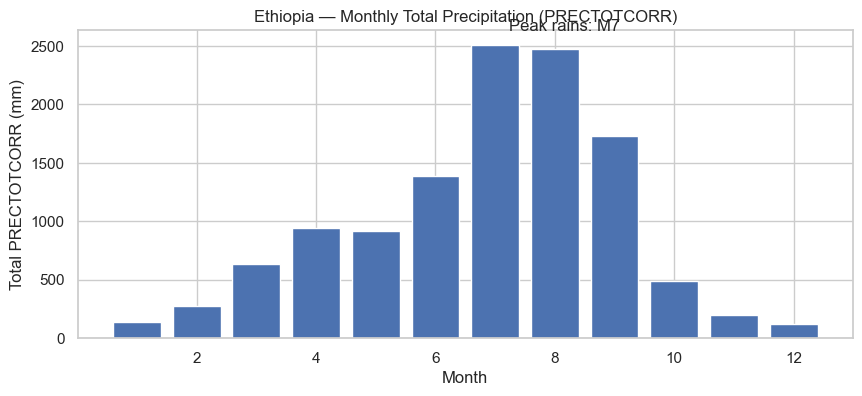

In [10]:
# 2) Monthly total precipitation bar chart + peak rainy season annotation
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly["Month"], monthly["PRECTOTCORR_sum"])
ax.set_title(f"{COUNTRY.title()} — Monthly Total Precipitation (PRECTOTCORR)")
ax.set_xlabel("Month")
ax.set_ylabel("Total PRECTOTCORR (mm)")

peak = monthly.loc[monthly["PRECTOTCORR_sum"].idxmax()]
ax.annotate(f"Peak rains: M{int(peak['Month'])}",
            (peak["Month"], peak["PRECTOTCORR_sum"]),
            textcoords="offset points", xytext=(10, 10))
plt.show()


## Interpretation (Monthly precipitation)

The precipitation bar chart highlights the seasonality of rainfall and the peak rainy month. This is a simple way to identify the main wet season and discuss potential flood risk vs. dry-season water stress.


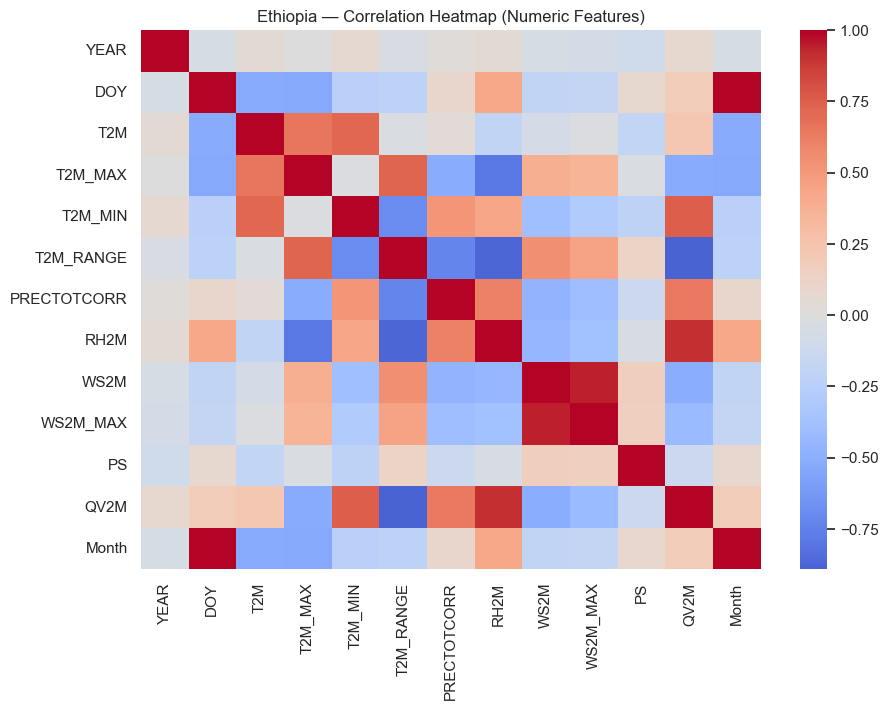

In [11]:
# 3) Correlation heatmap (numeric)
num = df.select_dtypes(include=[np.number]).copy()
corr = num.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title(f"{COUNTRY.title()} — Correlation Heatmap (Numeric Features)")
plt.show()


## Interpretation (Correlation)

Correlations show which variables move together (e.g., temperature relationships across max/min, or wind components). Strong relationships can suggest shared drivers or measurement coupling, but correlation does not imply causation.


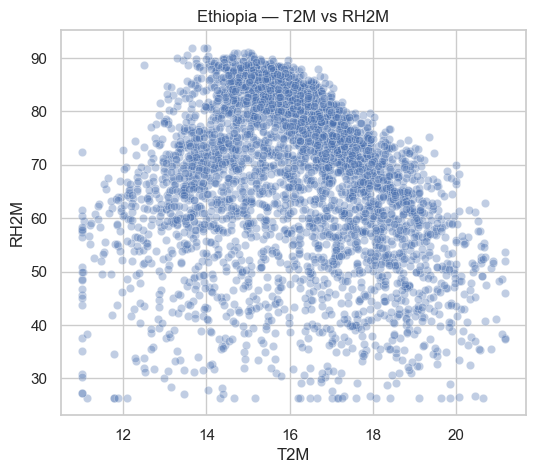

In [12]:
# 4) Scatter: T2M vs RH2M
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.35)
plt.title(f"{COUNTRY.title()} — T2M vs RH2M")
plt.show()


## Interpretation (T2M vs RH2M)

This scatterplot helps assess how humidity changes with temperature. A negative pattern is common in some climates (warmer days often coincide with lower relative humidity), which can amplify heat stress impacts.


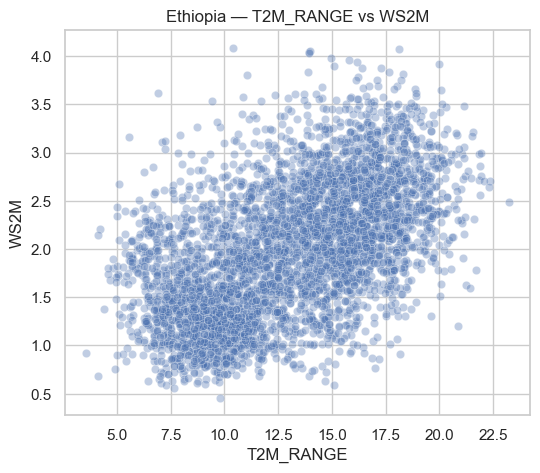

In [13]:
# 5) Scatter: T2M_RANGE vs WS2M
if "T2M_RANGE" in df.columns and "WS2M" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.35)
    plt.title(f"{COUNTRY.title()} — T2M_RANGE vs WS2M")
    plt.show()
else:
    print("T2M_RANGE or WS2M missing; cannot plot.")


## Interpretation (T2M_RANGE vs WS2M)

Daily temperature range is influenced by cloud cover, moisture, and winds. This plot provides a quick diagnostic: windy regimes can reduce temperature range via mixing, while calm clear days can show larger ranges.


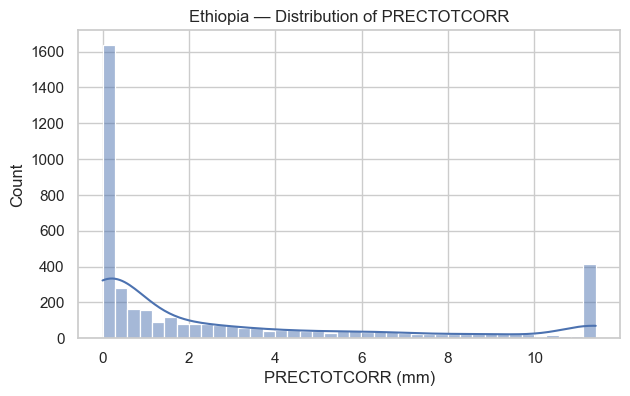

In [14]:
# 6) Histogram of PRECTOTCORR
plt.figure(figsize=(7, 4))
sns.histplot(df["PRECTOTCORR"].dropna(), bins=40, kde=True)
plt.title(f"{COUNTRY.title()} — Distribution of PRECTOTCORR")
plt.xlabel("PRECTOTCORR (mm)")
plt.show()


## Interpretation (Precipitation distribution)

Daily precipitation is usually right-skewed: many low/zero-rain days with fewer heavy-rain days. The tail of the distribution is important for flood and extreme-rainfall narratives.


In [ ]:
# 7) Bubble chart: T2M vs RH2M with PRECTOTCORR as bubble size
plt.figure(figsize=(7, 5))
sizes = (df["PRECTOTCORR"].fillna(0).clip(0, df["PRECTOTCORR"].quantile(0.99)) + 0.1) * 10
plt.scatter(df["T2M"], df["RH2M"], s=sizes, alpha=0.25)
plt.title(f"{COUNTRY.title()} — T2M vs RH2M (bubble size = PRECTOTCORR)")
plt.xlabel("T2M (°C)")
plt.ylabel("RH2M (%)")
plt.show()

## Interpretation (Bubble chart)

This view combines temperature–humidity conditions with rainfall intensity. Large bubbles clustering in certain temperature/humidity ranges can indicate the atmospheric regimes associated with rainfall events.
